# 📊 Customer Churn Prediction Project

This project analyzes customer behavior and builds a machine learning model to predict churn.

## 🎯 Objective

Identify key factors driving churn and build a predictive model to help businesses retain customers.

## 📦 Step 1: Import Libraries

Import required Python libraries for data analysis and modeling.

In [3]:
import pandas as pd
import numpy as np

## 📥 Step 2: Load Dataset

Load the dataset and inspect initial structure.

In [5]:
df = pd.read_csv("E Commerce Dataset.csv")

In [10]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

## 🔍 Step 3: Exploratory Data Analysis (EDA)

Understand patterns, distributions, and relationships in the data.

In [13]:
df['Churn'].value_counts(normalize = True)

Churn
0    0.831616
1    0.168384
Name: proportion, dtype: float64

In [21]:
df.groupby('Gender')['Churn'].mean()

Gender
Female    0.154942
Male      0.177305
Name: Churn, dtype: float64

In [22]:
df.groupby('Complain')['Churn'].mean()

Complain
0    0.109290
1    0.316708
Name: Churn, dtype: float64

In [23]:
from scipy.stats import ttest_ind

group1 = df[df['Complain']==0]['Churn']
group2 = df[df['Complain']==1]['Churn']

stat, p_value = ttest_ind(group1, group2)

print(f'P-value is {p_value}')

P-value is 4.282981610342116e-81


Complaint has a statistically significant effect on churn
 Business Translation:

“Customers who complain are significantly more likely to churn, and this relationship is not due to random chance.”

In [26]:
df.groupby('SatisfactionScore')['Churn'].mean()

SatisfactionScore
1    0.115120
2    0.126280
3    0.171967
4    0.171322
5    0.238267
Name: Churn, dtype: float64

In [30]:
pd.crosstab(df['SatisfactionScore'], df['Churn'], margins = True)

Churn,0,1,All
SatisfactionScore,,,
1,1030,134,1164
2,512,74,586
3,1406,292,1698
4,890,184,1074
5,844,264,1108
All,4682,948,5630


In [32]:
df.groupby('SatisfactionScore')['Complain'].mean()

SatisfactionScore
1    0.319588
2    0.290102
3    0.277974
4    0.249534
5    0.290614
Name: Complain, dtype: float64

In [33]:
df.groupby('Churn')['Tenure'].mean()

Churn
0    11.502334
1     3.379469
Name: Tenure, dtype: float64

In [37]:
print(df.groupby('Churn')['Tenure'].describe())

        count       mean       std  min  25%   50%   75%   max
Churn                                                         
0      4499.0  11.502334  8.419217  0.0  5.0  10.0  17.0  61.0
1       867.0   3.379469  5.486089  0.0  0.0   1.0   3.0  21.0


In [41]:
df.groupby('Churn')['OrderCount'].mean()

Churn
0    3.046601
1    2.823656
Name: OrderCount, dtype: float64

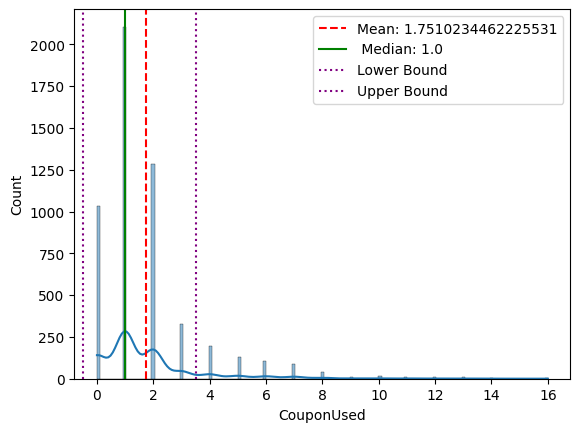

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
mean_val = df['CouponUsed'].mean()
median_val = df['CouponUsed'].median()

sns.histplot(df['CouponUsed'], kde= True)

plt.axvline(mean_val, color='Red',linestyle = '--', label = f"Mean: {mean_val}")
plt.axvline(median_val, color = 'Green', label = f" Median: {median_val}")

# Outlier boundaries
plt.axvline(lower_bound, color='purple', linestyle=':', label='Lower Bound')
plt.axvline(upper_bound, color='purple', linestyle=':', label='Upper Bound')

plt.legend()
plt.show()

## 🧹 Step 4: Data Cleaning

Handle missing values and ensure data quality.

In [80]:
df.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [44]:
df['Tenure'].median()

np.float64(9.0)

In [45]:
df['Tenure'].fillna(df['Tenure'].median(), inplace =True)

In [50]:
df['WarehouseToHome'].median()
df['WarehouseToHome'].fillna(df['WarehouseToHome'].median(), inplace=True)

C:\Users\ros12\AppData\Local\Temp\ipykernel_46896\2016396372.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['WarehouseToHome'].fillna(df['WarehouseToHome'].median(), inplace=True)


In [52]:
df['HourSpendOnApp'].fillna(df['HourSpendOnApp'].mean(), inplace = True)

C:\Users\ros12\AppData\Local\Temp\ipykernel_46896\2482215296.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['HourSpendOnApp'].fillna(df['HourSpendOnApp'].mean(), inplace = True)


In [78]:
cols_with_nulls



Index(['OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder'],
      dtype='object')

In [79]:
df['OrderAmountHikeFromlastYear'].fillna(df['OrderAmountHikeFromlastYear'].mean(), inplace=True)
df['CouponUsed'].fillna(df['CouponUsed'].median(), inplace= True)
df['OrderCount'].fillna(df['OrderCount'].median(), inplace = True)
df['DaySinceLastOrder'].fillna(df['DaySinceLastOrder'].median(), inplace = True)

C:\Users\ros12\AppData\Local\Temp\ipykernel_46896\2036312683.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['OrderAmountHikeFromlastYear'].fillna(df['OrderAmountHikeFromlastYear'].mean(), inplace=True)
C:\Users\ros12\AppData\Local\Temp\ipykernel_46896\2036312683.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are s

## 🔄 Step 5: Encoding

Convert categorical variables into numerical format using one-hot encoding.

In [ ]:
#Dropping irrelevant columns
df = df.drop('CustomerID', axis = 1)

In [83]:
#One hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

In [88]:
print(df_encoded.columns)
print(df_encoded.shape)

Index(['Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
       'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount',
       'PreferredLoginDevice_Mobile Phone', 'PreferredLoginDevice_Phone',
       'PreferredPaymentMode_COD', 'PreferredPaymentMode_Cash on Delivery',
       'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card',
       'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI',
       'Gender_Male', 'PreferedOrderCat_Grocery',
       'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile',
       'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others',
       'MaritalStatus_Married', 'MaritalStatus_Single'],
      dtype='object')
(5630, 30)


## ✂️ Step 6: Train-Test Split

Split data into training and testing sets for model evaluation.

In [91]:
# Train Test Split
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn',axis =1 )
y = df_encoded['Churn']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [92]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4504, 29)
(1126, 29)
(4504,)
(1126,)


## 🤖 Step 7: Model Building (Logistic Regression)

Train a baseline classification model.

In [93]:
#Logistic Regression
#“We choose Logistic Regression because it is simple, interpretable, and suitable for binary classification, making it a strong baseline model.”

In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy is {accuracy}")

Accuracy is 0.91651865008881


c:\Users\ros12\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [105]:
#Sclaing data before model testing

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

steps = [('scaler',StandardScaler()),
         ('model', LogisticRegression(max_iter = 1000))]

pipeline = Pipeline(steps)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy score is {accuracy}')


Accuracy score is 0.9156305506216696


## ⚖️ Step 8: Handling Imbalance

Use class weights to improve recall for churn prediction.

In [ ]:
#Tuning model with class_weight

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

steps = [('scaler',StandardScaler()),
         ('model', LogisticRegression(max_iter =1000, class_weight = 'balanced'))]

pipeline = Pipeline(steps)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.83      0.89       941
           1       0.48      0.83      0.61       185

    accuracy                           0.83      1126
   macro avg       0.72      0.83      0.75      1126
weighted avg       0.88      0.83      0.84      1126



## 📈 Step 9: Evaluation

Evaluate model using accuracy, confusion matrix, and classification report.

In [106]:
#Using Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[924  17]
 [ 78 107]]


In [107]:
#Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95       941
           1       0.86      0.58      0.69       185

    accuracy                           0.92      1126
   macro avg       0.89      0.78      0.82      1126
weighted avg       0.91      0.92      0.91      1126



In [104]:
#“The model performs well overall but struggles to identify churners, missing ~42% of them. This limits its effectiveness for retention strategies.”

## 📉 Step 10: ROC-AUC

Assess model performance across thresholds.

AUC: 0.894057500646236


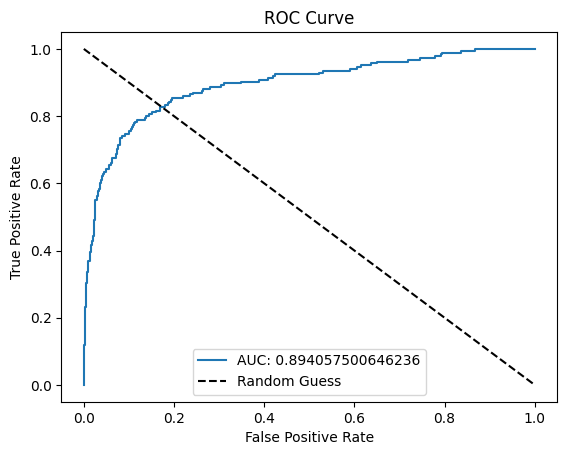

In [114]:
#ROC/AUC
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = pipeline.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)
print(f'AUC: {auc}')

import matplotlib.pyplot as plt
plt.plot(fpr,tpr, label = f'AUC: {auc}')
plt.plot([0,1], [1,0], 'k--', label = 'Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## 🎛️ Step 11: Threshold Tuning

Adjust classification threshold to improve recall.

In [116]:
#Threshold Tuning
y_pred_custom = (y_prob >= 0.3).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.97      0.66      0.79       941
           1       0.34      0.90      0.50       185

    accuracy                           0.70      1126
   macro avg       0.66      0.78      0.64      1126
weighted avg       0.87      0.70      0.74      1126



## 🔍 Step 12: Feature Importance

Identify key drivers of churn.

In [119]:
#Feature Importance
coefficients = pipeline.named_steps['model'].coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending = False)

print(feature_importance.head(10))

                                  Feature  Coefficient
7                                Complain     0.727566
6                         NumberOfAddress     0.643738
26                PreferedOrderCat_Others     0.548658
5                       SatisfactionScore     0.400664
1                                CityTier     0.359549
28                   MaritalStatus_Single     0.358279
4                NumberOfDeviceRegistered     0.347560
2                         WarehouseToHome     0.311147
10                             OrderCount     0.297991
16  PreferredPaymentMode_Cash on Delivery     0.256254


## 💼 Conclusion

Summarize findings and business insights.